In [10]:
from diffusers import StableDiffusionPipeline
import torch
import numpy as np

100%|██████████| 50/50 [00:07<00:00,  6.36it/s]


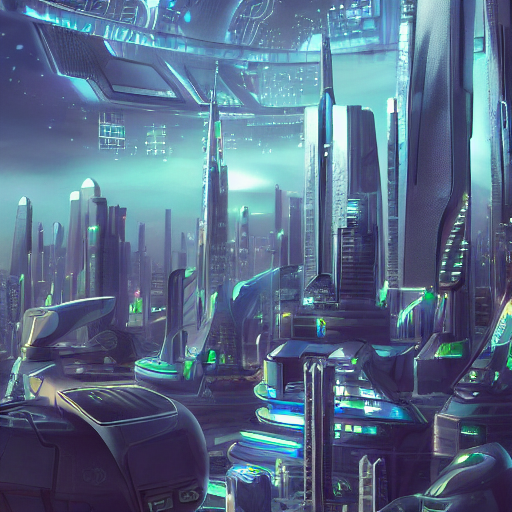

100%|██████████| 50/50 [00:06<00:00,  7.79it/s]


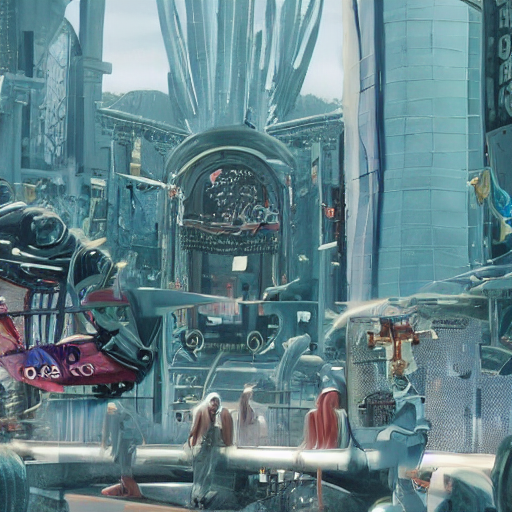

In [ ]:
# Unsurprisingly image generators have implemented classifer free guidance with the "guidance_scale" parameter. 
# We can see the results do speak for themselves in the images below.
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to("cuda")

#Context free guidance (cfg) on:
image = pipe("a futuristic city", guidance_scale=7.5).images[0]
display(image)

# CFG off:
image = pipe("a futuristic city", guidance_scale=0).images[0]
display(image)



100%|██████████| 50/50 [00:08<00:00,  5.97it/s]


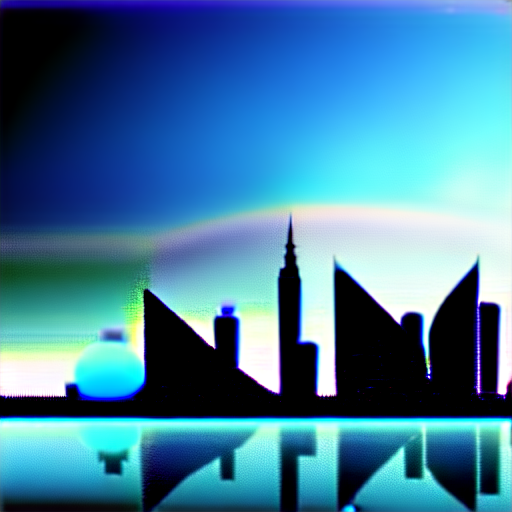

In [ ]:
#Context free guidance (cfg) on turned up very high, we can see below that there is a limit for 
# how high we can set this value. 
image = pipe("a futuristic city", guidance_scale=100).images[0]
display(image)

In [18]:
# Lets see if we can hyperparamter guidance_scale in a GAN style. 
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    torch_dtype=torch.float16
    ).to('cuda')

clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def clip_score(image: Image.Image, prompt: str) -> float:
    inputs = clip_processor(
        text=[prompt],
        images=image,
        return_tensors='pt',
        padding=True
    ).to("cuda")

    with torch.no_grad():
        outputs = clip_model(**inputs)
        score = outputs.logits_per_image[0, 0].item()

    return score    

def tune_guidance(prompt, scales=[i for i in range(0, 100, 2)]):
    best_score = -np.inf
    best_image = None
    best_scale = None

    for scale in scales:
        print(f"Testing guidance_scale={scale}")
        image = pipe(prompt, guidance_scale=scale).images[0]
        score = clip_score(image, prompt)
        print(f"CLIP score = {score}")

    if score > best_score:
        best_score = score
        best_image = image
        best_scale = scale

    print(f"\nBest scale = {best_scale} (score={best_score})")
    return best_image, best_score    


In [ ]:
image, best_scale = tune_guidance("a futuristic city")


Testing guidance_scale=0


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:06<00:00,  7.17it/s]


CLIP score = 25.0
Testing guidance_scale=2


100%|██████████| 50/50 [00:07<00:00,  6.26it/s]


...

100%|██████████| 50/50 [00:08<00:00,  5.74it/s]


CLIP score = 29.421875
Testing guidance_scale=98


100%|██████████| 50/50 [00:07<00:00,  6.47it/s]


CLIP score = 29.046875

Best scale = 98 (score=29.046875)
29.046875


/snap/core20/current/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /home/dsu/snap/code/common/.cache/gio-modules/libgiolibproxy.so
eog: symbol lookup error: /snap/core20/current/lib/x86_64-linux-gnu/libpthread.so.0: undefined symbol: __libc_pthread_init, version GLIBC_PRIVATE


29.046875


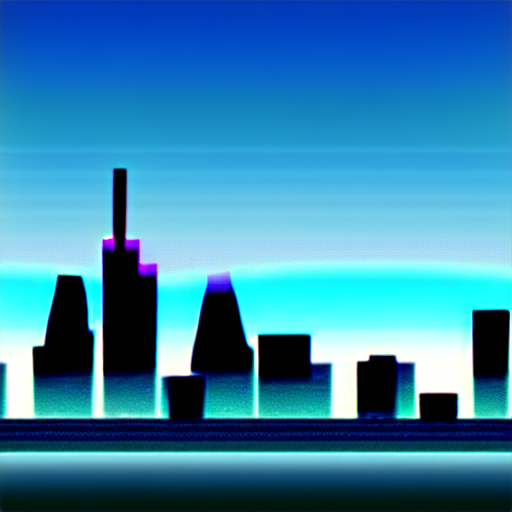

In [20]:
print(best_scale)
display(image)